In [1]:
import warnings
warnings.filterwarnings('ignore')
!pip install numpy
!pip install -U "cupy-cuda13x[ctk]"
!pip install types-array-api
!pip install array-api-compat

In [2]:
!git clone https://github.com/Ankit-539/QuanSToS.git

fatal: destination path 'QuanSToS' already exists and is not an empty directory.


In [3]:
%cd QuanSToS

/content/QuanSToS


In [6]:
import math
from time import perf_counter

import numpy as np
from array_api.latest import Array, ArrayNamespace
import array_api_compat
import array_api_compat.cupy as cp
import matplotlib.pyplot as plt

from src import (
    get_random_haar,
    get_random_mixed,
    get_random_product,
    get_random_product_pole_biased,
    inverse_estimator,
    negativity,
    pauli_measurement,
    plot_counts,
    bloch_vector,
    benchmark_function,
    benchmark_pauli_measurement
)

# Virtual Pauli measurements

XXX  [12461 12553 12366 12526 12626 12361 12530 12577]
XXY  [12616 12471 12504 12362 12470 12562 12547 12468]
XXZ  [21436  3860 21424  3806 21024  3653 21091  3706]
XYX  [12460 12372 12696 12425 12671 12454 12317 12605]
XYY  [12518 12599 12508 12648 12458 12391 12454 12424]
XYZ  [21204  3720 21081  3706 21453  3734 21383  3719]
XZX  [21350 21205  3766  3719 21093 21340  3778  3749]
XZY  [21276 21262  3780  3748 21419 21032  3749  3734]
XZZ  [38777  3784  3784  3691 38615  3775  3817  3757]
YXX  [12413 12575 12504 12692 12512 12437 12423 12444]
YXY  [12518 12428 12572 12440 12729 12360 12584 12369]
YXZ  [21146  3745 21419  3765 21375  3774 21107  3669]
YYX  [12553 12443 12659 12439 12401 12543 12446 12516]
YYY  [12402 12505 12533 12373 12626 12592 12505 12464]
YYZ  [21161  3716 21164  3829 21428  3734 21191  3777]
YZX  [21202 21340  3688  3815 21241 21274  3667  3773]
YZY  [21343 21227  3649  3713 21266 21320  3714  3768]
YZZ  [38757  3658  3739  3653 38905  3765  3760  3763]
ZXX  [2122

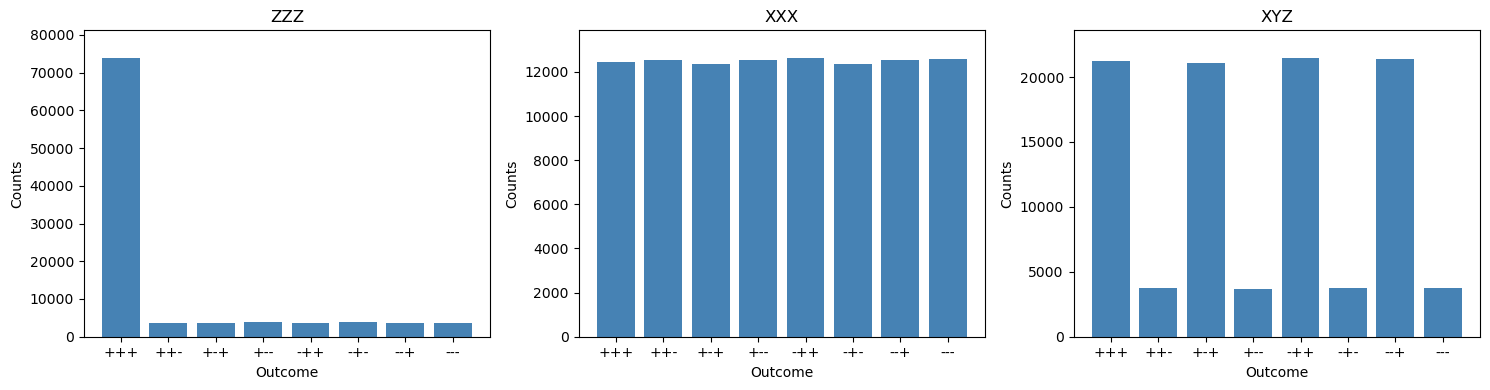

In [7]:
p = 0.7
rho_000 = np.zeros((8, 8), dtype=np.complex128)
rho_000[0, 0] = 1
rho_partial = (p*rho_000 + (1-p)*np.eye(8, dtype=np.complex128)/8)

N = 100_000

result = pauli_measurement(rho_partial, N)

print(result)

plot_counts(result,["ZZZ", "XXX", "XYZ"])

XXX  [12377 12710 12521 12500 12603 12478 12638 12173]
XXY  [12533 12482 12584 12440 12548 12433 12430 12550]
XXZ  [24904     0 24930     0 25106     0 25060     0]
XYX  [12605 12727 12203 12402 12628 12556 12479 12400]
XYY  [12481 12495 12497 12498 12630 12504 12530 12365]
XYZ  [24746     0 25150     0 25099     0 25005     0]
XZX  [24964 25223     0     0 24891 24922     0     0]
XZY  [24806 24873     0     0 25145 25176     0     0]
XZZ  [49960     0     0     0 50040     0     0     0]
YXX  [12463 12449 12430 12533 12578 12585 12590 12372]
YXY  [12465 12644 12426 12555 12518 12544 12489 12359]
YXZ  [25016     0 25101     0 24833     0 25050     0]
YYX  [12310 12537 12511 12691 12444 12525 12502 12480]
YYY  [12464 12330 12533 12542 12512 12441 12660 12518]
YYZ  [25069     0 24591     0 25323     0 25017     0]
YZX  [25031 24873     0     0 24947 25149     0     0]
YZY  [24857 25203     0     0 24974 24966     0     0]
YZZ  [50174     0     0     0 49826     0     0     0]
ZXX  [2508

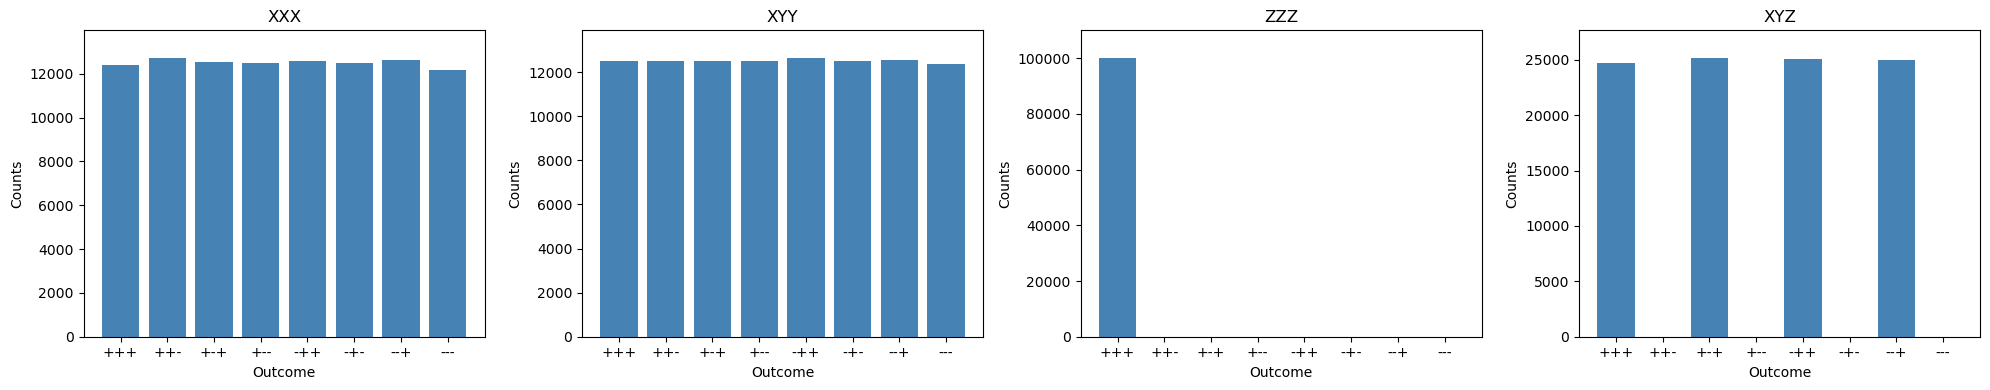

In [8]:
rho_000_cp = cp.zeros((8, 8), dtype=cp.complex128)
rho_000_cp[0, 0] = 1

N = 100_000

result_cp = pauli_measurement(rho_000_cp, N)

print(result_cp)
plot_counts(
    result_cp,
    ["XXX", "XYY", "ZZZ", "XYZ"]
)

100000


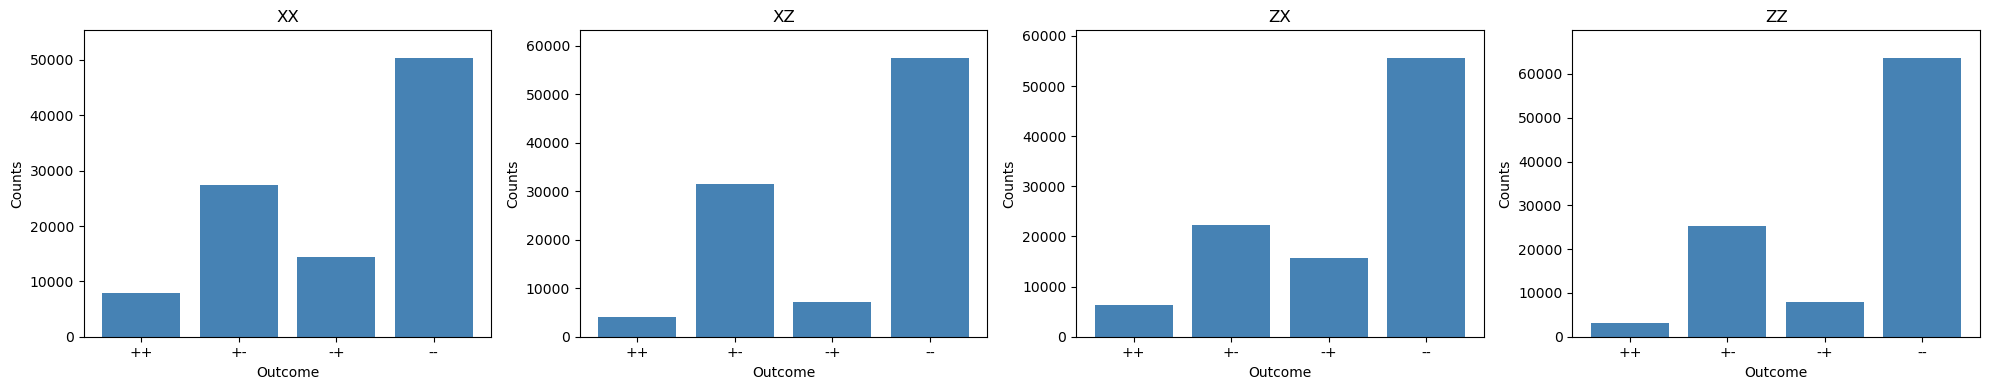

In [9]:
rho = get_random_product(2, array_api_compat.numpy, np.random)

N = 100_000

result = pauli_measurement(rho, N)

print(result.N)

plot_counts(result, ["XX", "XZ", "ZX", "ZZ"])

100000


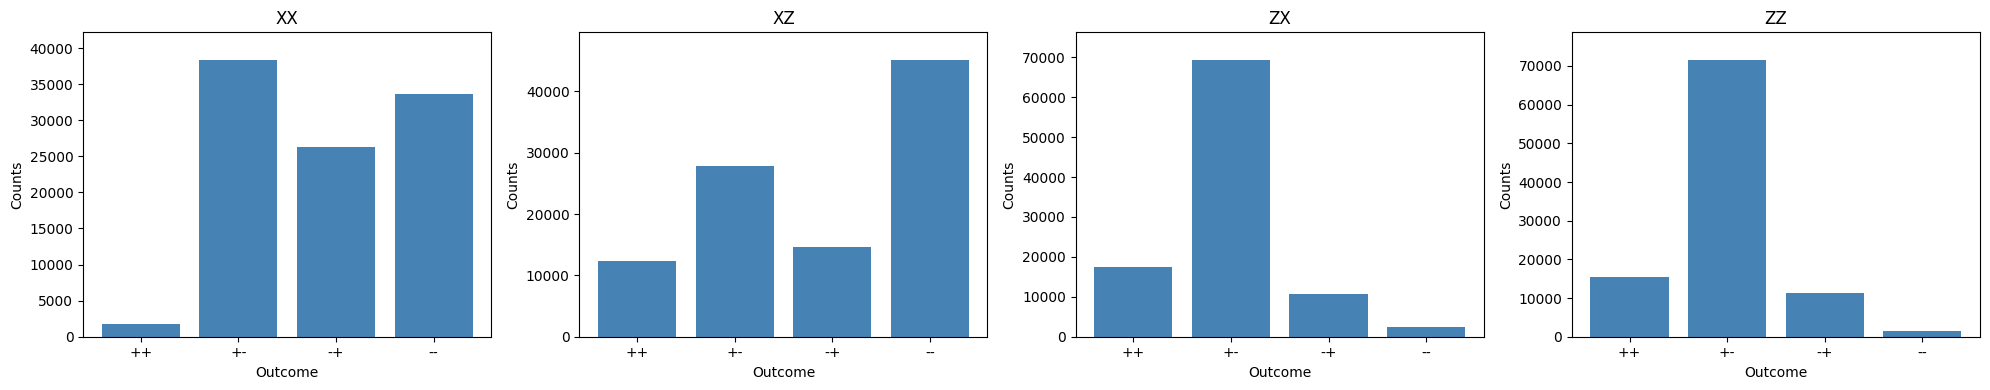

In [8]:
rho = get_random_haar(2, array_api_compat.numpy, np.random)

N = 100_000

result = pauli_measurement(rho, N)

print(result.N)

plot_counts(result, ["XX", "XZ", "ZX", "ZZ"])

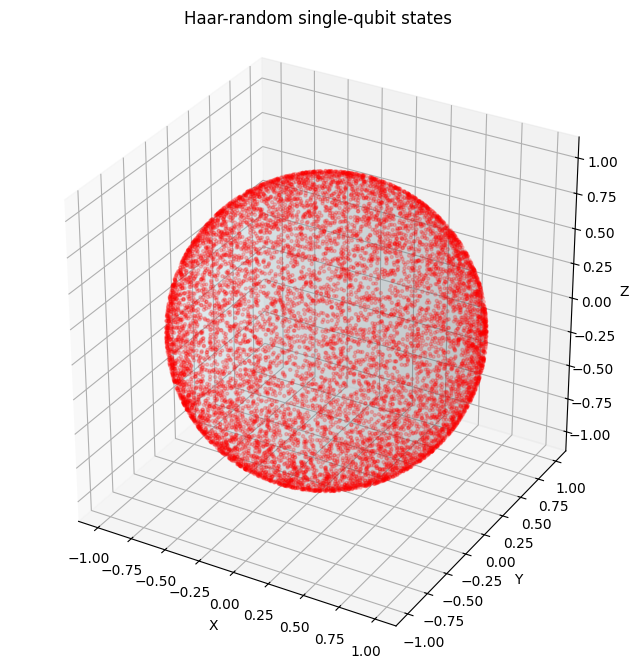

In [9]:
bloch_vectors = []
num_samples = 10000

for _ in range(num_samples):
    rho = get_random_haar(1, array_api_compat.numpy, np.random)
    r = bloch_vector(rho)
    bloch_vectors.append(r)

rng = np.random.default_rng(42)

vectors_np = np.asarray(bloch_vectors)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Bloch sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)

x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(
    x_sphere,
    y_sphere,
    z_sphere,
    color="lightblue",
    alpha=0.15,
    linewidth=0
)

# Haar-random states
ax.scatter(
    vectors_np[:, 0],
    vectors_np[:, 1],
    vectors_np[:, 2],
    s=5,
    alpha=0.2,
    color="red"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Haar-random single-qubit states")

ax.set_box_aspect([1, 1, 1])

plt.show()

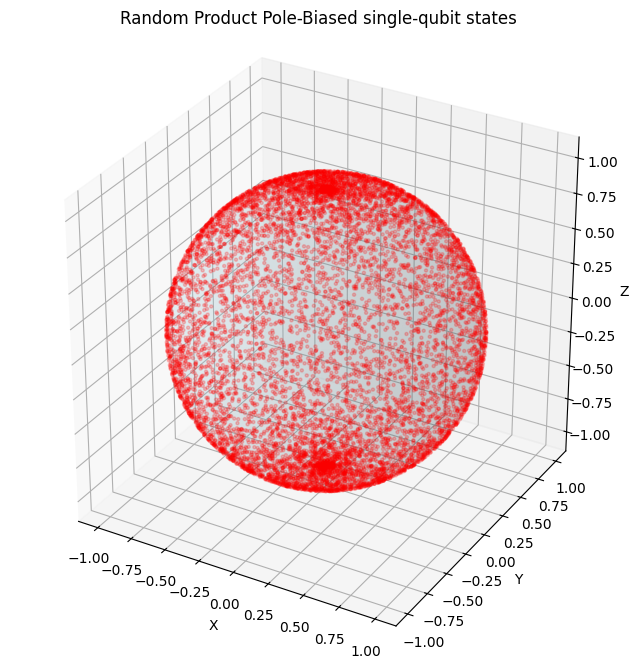

In [10]:
bloch_vectors = []
num_samples = 10000

for _ in range(num_samples):
    rho = get_random_product_pole_biased(1, array_api_compat.numpy, np.random)
    r = bloch_vector(rho)
    bloch_vectors.append(r)

rng = np.random.default_rng(42)

vectors_np = np.asarray(bloch_vectors)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Bloch sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)

x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(
    x_sphere,
    y_sphere,
    z_sphere,
    color="lightblue",
    alpha=0.15,
    linewidth=0
)

# Haar-random states
ax.scatter(
    vectors_np[:, 0],
    vectors_np[:, 1],
    vectors_np[:, 2],
    s=5,
    alpha=0.2,
    color="red"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Random Product Pole-Biased single-qubit states")

ax.set_box_aspect([1, 1, 1])

plt.show()

In [11]:
xp = np

zero = xp.asarray([1, 0], dtype=xp.complex128)
plus = xp.asarray([1, 1], dtype=xp.complex128) / xp.sqrt(2)

psi = xp.kron(zero, plus)
rho = xp.outer(psi, xp.conj(psi))

result = pauli_measurement(rho, 100_000)

for measurement in ["ZX", "XZ"]:
    i = result.measurements.index(measurement)
    print(measurement, result.counts[i])

ZX [100000      0      0      0]
XZ [25025 24752 25085 25138]


XY [25023 24827 25023 25127]
YX [50009     0 49991     0]


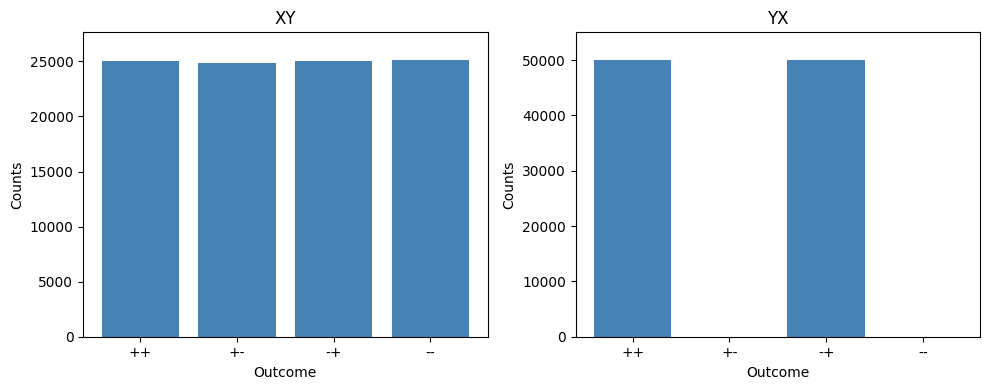

In [12]:
zero = xp.asarray([1, 0], dtype=xp.complex128)
one  = xp.asarray([0, 1], dtype=xp.complex128)

plus_x = (zero + one) / xp.sqrt(2)
plus_y = (zero + 1j * one) / xp.sqrt(2)

psi = xp.kron(plus_x, plus_y)
rho = xp.outer(psi, xp.conj(psi))

for measurement in ["XY", "YX"]:
    i = result.measurements.index(measurement)
    print(measurement, result.counts[i])

plot_counts(result, ["XY", "YX"])

# Hardware Benchmarking

Sampling

In [10]:
benchmarks = {
    "Product": (
        get_random_product,
        range(2, 15)
    ),

    "Product (pole biased)": (
        get_random_product_pole_biased,
        range(2, 15)
    ),

    "Haar": (
        get_random_haar,
        range(2, 15)
    ),

    "Mixed": (
        get_random_mixed,
        range(2, 11)
    ),
}

functions = {
    "Product": get_random_product,
    "Product (pole biased)": get_random_product_pole_biased,
    "Haar": get_random_haar,
    "Mixed": get_random_mixed,
}

rng_np = np.random.default_rng(42)
rng_cp = cp.random.RandomState(42)

### CPU (NumPy)

In [14]:
results_np = {}

for name, (func, n_values) in benchmarks.items():

    print(f"Benchmarking NumPy: {name}")

    results_np[name] = benchmark_function(
        func,
        n_values,
        np,
        rng_np,
        repeats=20
    )

Benchmarking NumPy: Product
Benchmarking NumPy: Product (pole biased)
Benchmarking NumPy: Haar
Benchmarking NumPy: Mixed


### GPU (CuPy)

In [15]:
results_cp = {}

for name, (func, n_values) in benchmarks.items():

    print(f"Benchmarking CuPy: {name}")

    results_cp[name] = benchmark_function(
        func,
        n_values,
        cp,
        rng_cp,
        repeats=10
    )

Benchmarking CuPy: Product
Benchmarking CuPy: Product (pole biased)
Benchmarking CuPy: Haar
Benchmarking CuPy: Mixed


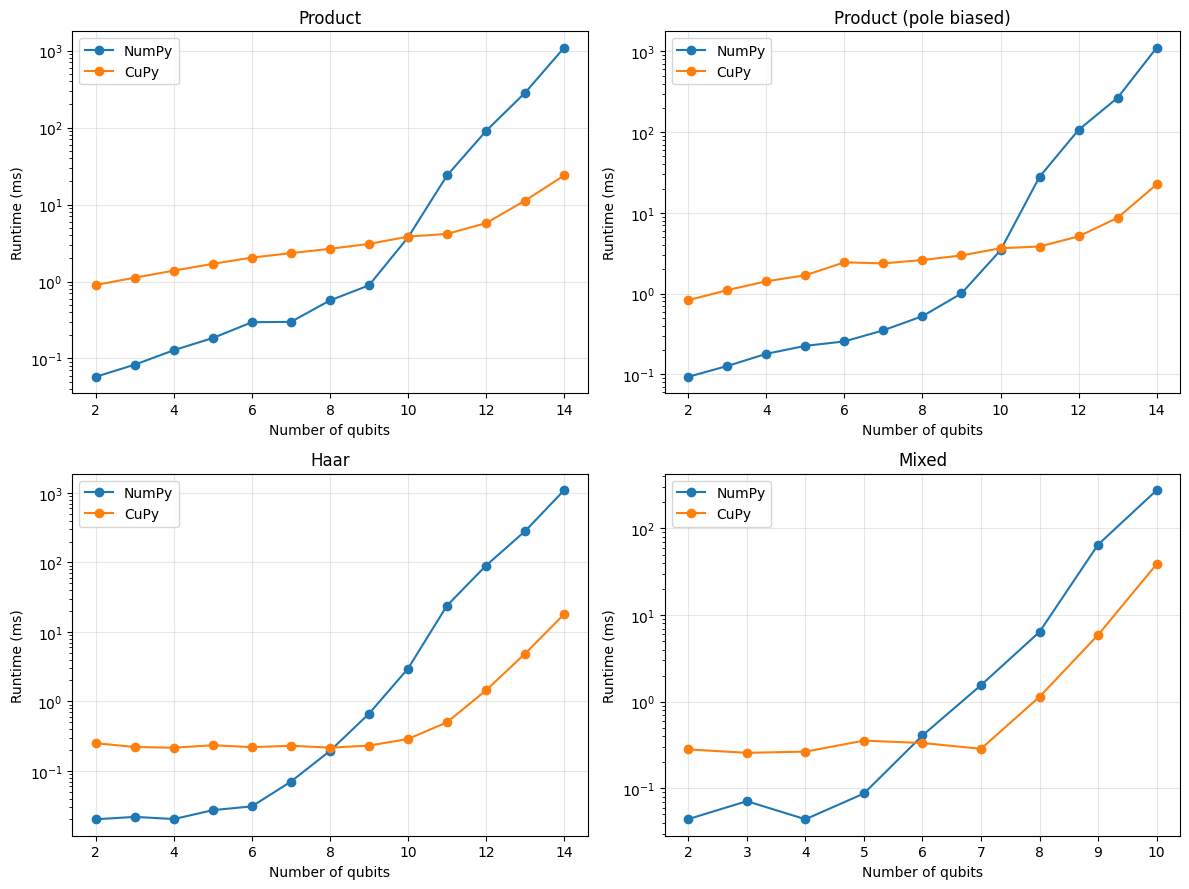

In [16]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9)
)

axes = axes.flatten()

for ax, (name, (func, n_values)) in zip(axes, benchmarks.items()):

    n_values = list(n_values)

    ax.plot(
        n_values,
        results_np[name],
        marker="o",
        label="NumPy"
    )

    ax.plot(
        n_values,
        results_cp[name],
        marker="o",
        label="CuPy"
    )

    ax.set_title(name)
    ax.set_xlabel("Number of qubits")
    ax.set_ylabel("Runtime (ms)")
    ax.set_yscale("log")

    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

Virtual Measurement

In [ ]:
n_values = range(2, 9)

N = 10_000

### CPU (NumPy)

In [ ]:
results_np = {}

for n in n_values:

    print(f"Benchmarking n = {n}")

    rho_np = get_random_haar(n, np, rng_np)

    results_np[n] = benchmark_pauli_measurement(pauli_measurement, rho_np, N, np, repeats=5)

### GPU (CuPy)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(results_np.keys()),
    list(results_np.values()),
    marker="o",
    label="NumPy"
)

plt.plot(
    list(results_cp.keys()),
    list(results_cp.values()),
    marker="o",
    label="CuPy"
)

plt.yscale("log")

plt.xlabel("Number of qubits")
plt.ylabel("Runtime (ms)")
plt.title("Pauli Measurement Benchmark")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
results_cp = {}

for n in n_values:

    print(f"Benchmarking n = {n}")

    rho_cp = get_random_haar(n, cp, rng_cp)

    results_cp[n] = benchmark_pauli_measurement(pauli_measurement, rho_cp, N, cp, repeats=5)

# Noise Resilience

In [12]:
def get_accuracy_negativity(rho: Array, Ns: list[int]
    ) -> tuple[list[float], list[float]]:
    xp = array_api_compat.array_namespace(rho)

    countss = []
    for N in Ns:
        counts = pauli_measurement(rho, N).counts
        countss.append(counts)

    fs = []
    ns = []
    for i, N in enumerate(Ns):
        counts = countss[i]
        est = inverse_estimator(counts)

        f = float(xp.linalg.norm(rho - est))
        fs.append(f)

        n = float(negativity(est))
        ns.append(n)

    return fs, ns

n = 4
Ns = list(2**i for i in range(3, 20))
xp = np
rng = rng_np
m = 10
names = ['product', 'Haar', 'mixed']
gens = [get_random_product, get_random_haar, get_random_mixed]
mean_fss = []
mean_nss = []
for i, gen in enumerate(gens):
    rho = gen(n, xp, rng)
    fss = []
    nss = []
    for j in range(m):
        fs, ns = get_accuracy_negativity(rho, Ns)
        fss.append(fs)
        nss.append(ns)

    fss = np.asarray(fss)
    nss = np.asarray(nss)

    mean_fs = np.mean(fss, 0)
    mean_ns = np.mean(nss, 0)

    mean_fss.append(list(mean_fs))
    mean_nss.append(list(mean_ns))

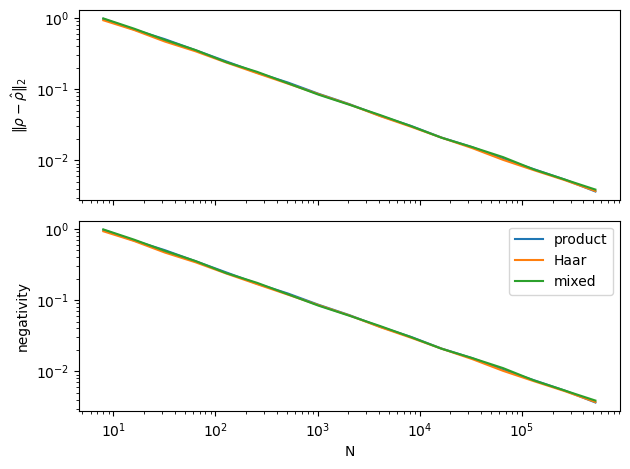

In [13]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True)

# Accuracy
for name, fs in zip(names, mean_fss):
    ax1.plot(Ns, fs, label=name)

# plt.xlabel('N')
ax1.set_ylabel(r'$\| \rho - \hat\rho \|_2$')
# plt.legend(loc='best')

ax1.set_xscale('log')
ax1.set_yscale('log')

# Negativity
for name, fs in zip(names, mean_fss):
    ax2.plot(Ns, fs, label=name)

ax2.set_xlabel('N')
ax2.set_ylabel('negativity')

ax2.set_xscale('log')
ax2.set_yscale('log')

plt.legend(loc='best')
plt.tight_layout()

plt.savefig('../plots/accuracy_negativity.pdf')

plt.show()
plt.close()